In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as ctx
import pandas as pd
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 500)

In [14]:
with open('../data/gdf_ht.pickle', 'rb') as file:
    gdf_ht =  pickle.load(file)

In [15]:
with open('../data/warsaw.pickle', 'rb') as file:
    warsaw =  pickle.load(file)

In [16]:
with open('../data/powiaty_maz.pickle', 'rb') as file:
    powiaty_maz =  pickle.load(file)

In [17]:
with open('../data/dzielnice.pickle', 'rb') as file:
    dzielnice =  pickle.load(file)

In [18]:
with open('../data/gdf.pickle', 'rb') as file:
    gdf =  pickle.load(file)

In [22]:
with open('../data/gdf_FRNN.pickle', 'rb') as file:
    gdf_FRNN =  pickle.load(file)

In [23]:
pkd7 = pd.read_excel('../data/PKD7_HT_2.xlsx')

In [25]:
gdf = pd.merge(gdf, pkd7, on='PKD7', how='left')
gdf['tech'].fillna('other', inplace=True)

C:\Users\Filip\AppData\Local\Temp\ipykernel_28036\3735970920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf['tech'].fillna('other', inplace=True)


In [26]:
gdf['Group'].value_counts()

Group
O        849747
HTKIS     56774
MLT       37023
LT        30192
MHT        7806
HT         2173
Name: count, dtype: int64

## 1x1 km grid 

In [28]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import warnings
import math

# Suppress all warnings
warnings.filterwarnings("ignore")

# Function for grid size calculation
def calculate_grid_size(lat):
    earth_radius_km = 6371  
    one_km_in_degrees_lat = 1 / (earth_radius_km * np.pi / 180)  
    one_km_in_degrees_lon = 1 / (earth_radius_km * np.pi / 180 * math.cos(math.radians(lat)))  
    return min(one_km_in_degrees_lat, one_km_in_degrees_lon)

# Function for grid calculation
def create_grid(min_lon, max_lon, min_lat, max_lat):
    # Calculate the number of grid cells needed to achieve 1x1km grid cells
    num_cells_x = int(np.ceil((max_lon - min_lon) / grid_size))
    num_cells_y = int(np.ceil((max_lat - min_lat) / grid_size))

    # Generate grid of lon and lat values
    lons = np.linspace(min_lon, max_lon, num_cells_x)
    lats = np.linspace(min_lat, max_lat, num_cells_y)

    # Create grid polygons
    polygons = []
    for x in range(len(lons) - 1):
        for y in range(len(lats) - 1):
            lon1, lon2 = lons[x], lons[x + 1]
            lat1, lat2 = lats[y], lats[y + 1]
            polygon = Polygon([(lon1, lat1), (lon1, lat2), (lon2, lat2), (lon2, lat1)])
            polygons.append(polygon)

    # Create GeoDataFrame for grid
    grid_gdf = gpd.GeoDataFrame(geometry=polygons)
    
    return grid_gdf

# Function to count firms in each grid cell
def count_firms_on_grid(group_df, group_name, grid_gdf):
    # Spatial join to count firms in each grid cell
    grid_with_counts = gpd.sjoin(grid_gdf, group_df, how="left", op='contains')
    grid_counts = grid_with_counts.groupby(grid_with_counts.index)['Group'].count().reset_index(name='firm_count')

    # Merge counts with grid GeoDataFrame
    grid_gdf_counted = grid_gdf.merge(grid_counts, left_index=True, right_on='index', how='left')
    grid_gdf_counted = grid_gdf_counted.set_index('index')

    return grid_gdf_counted

# Empty DataFrame to store the counts
counts_df = pd.DataFrame()

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

# Calculate the grid size based on the maximum latitude in the dataset
grid_size = calculate_grid_size(max_lat_all)

# Pre-calculate the grid
grid_gdf = create_grid(min_lon_all, max_lon_all, min_lat_all, max_lat_all)

group_names = ['HT', 'MHT', 'HTKIS', 'O', 'MLT', 'LT']

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    counted_df = count_firms_on_grid(group_df, group_name, grid_gdf)
    counts_df[group_name] = counted_df['firm_count']

grid_counts_final = grid_gdf.merge(counts_df, left_index=True, right_on='index', how='left')


In [37]:
grid_counts_final['firm_count'] = grid_counts_final[['O', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT']].sum(axis=1)

In [38]:
# Spatial join to select only grid cells within Mazowieckie
grid_counts_powiaty = gpd.sjoin(grid_counts_final, powiaty_maz, how='inner', op='within').reset_index()

In [39]:
grid_counts_powiaty

,index,geometry,HT,MHT,HTKIS,O,MLT,LT,firm_count,index_right,JPT_NAZWA_
0,972,"POLYGON ((19.29150 52.39525, 19.29150 52.40427...",0,0,0,4,0,0,4,62,powiat gostyniński
1,976,"POLYGON ((19.29150 52.43133, 19.29150 52.44036...",0,0,0,7,0,0,7,62,powiat gostyniński
2,1245,"POLYGON ((19.30051 52.39525, 19.30051 52.40427...",0,0,0,5,0,0,5,62,powiat gostyniński
3,1246,"POLYGON ((19.30051 52.40427, 19.30051 52.41329...",0,0,0,2,0,0,2,62,powiat gostyniński
4,1247,"POLYGON ((19.30051 52.41329, 19.30051 52.42231...",0,0,0,9,0,0,9,62,powiat gostyniński
...,...,...,...,...,...,...,...,...,...,...,...
51418,116163,"POLYGON ((23.09356 52.25993, 23.09356 52.26895...",0,0,0,2,0,0,2,60,powiat łosicki
51419,116164,"POLYGON ((23.09356 52.26895, 23.09356 52.27797...",0,0,0,29,0,1,30,60,powiat łosicki
51420,116165,"POLYGON ((23.09356 52.27797, 23.09356 52.28700...",0,0,0,0,0,0,0,60,powiat łosicki
51421,116438,"POLYGON ((23.10257 52.27797, 23.10257 52.28700...",0,0,0,16,0,2,18,60,powiat łosicki


In [32]:
aggregated_stats = grid_counts_powiaty.iloc[:, 2:9].agg(['sum', 'mean', 'std', 'min', 'max'], axis='rows')

# aggregated_stats.to_csv('../data/aggregated_statistics.csv')
aggregated_stats

,HT,MHT,HTKIS,O,MLT,LT,index_right
sum,2089.000000,7461.000000,54688.000000,808838.000000,34707.000000,28679.000000,1.116959e+07
mean,0.040624,0.145091,1.063493,15.729110,0.674931,0.557708,2.172099e+02
std,0.467574,1.710713,11.952437,104.645234,3.733494,3.964499,1.147708e+02
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+00
max,28.000000,184.000000,901.000000,7991.000000,160.000000,230.000000,3.680000e+02


In [40]:
groups = ['HT', 'MHT','HTKIS', 'O', 'MLT', 'LT']

In [41]:
# for group in groups:
#     group_count = grid_counts_powiaty[group].sum()
#     num_firms_total = 983791
#     grid_counts_powiaty[f'LQ_{group}'] = ((grid_counts_powiaty[group] / group_count)/(grid_counts_powiaty['firm_count'] / num_firms_total))*100

# grid_counts_powiaty.fillna(0)

In [42]:
for group in groups:
    group_count = grid_counts_powiaty[group].sum()
    num_firms_total = 983791
    grid_counts_powiaty[f'LQ_{group}'] = ((grid_counts_powiaty[group] / grid_counts_powiaty['firm_count'])/(group_count / num_firms_total))

grid_counts_powiaty.fillna(0)

,index,geometry,HT,MHT,HTKIS,O,MLT,LT,firm_count,index_right,JPT_NAZWA_,LQ_HT,LQ_MHT,LQ_HTKIS,LQ_O,LQ_MLT,LQ_LT
0,972,"POLYGON ((19.29150 52.39525, 19.29150 52.40427...",0,0,0,4,0,0,4,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
1,976,"POLYGON ((19.29150 52.43133, 19.29150 52.44036...",0,0,0,7,0,0,7,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
2,1245,"POLYGON ((19.30051 52.39525, 19.30051 52.40427...",0,0,0,5,0,0,5,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
3,1246,"POLYGON ((19.30051 52.40427, 19.30051 52.41329...",0,0,0,2,0,0,2,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
4,1247,"POLYGON ((19.30051 52.41329, 19.30051 52.42231...",0,0,0,9,0,0,9,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51418,116163,"POLYGON ((23.09356 52.25993, 23.09356 52.26895...",0,0,0,2,0,0,2,60,powiat łosicki,0.0,0.0,0.0,1.216302,0.0,0.000000
51419,116164,"POLYGON ((23.09356 52.26895, 23.09356 52.27797...",0,0,0,29,0,1,30,60,powiat łosicki,0.0,0.0,0.0,1.175758,0.0,1.143451
51420,116165,"POLYGON ((23.09356 52.27797, 23.09356 52.28700...",0,0,0,0,0,0,0,60,powiat łosicki,0.0,0.0,0.0,0.000000,0.0,0.000000
51421,116438,"POLYGON ((23.10257 52.27797, 23.10257 52.28700...",0,0,0,16,0,2,18,60,powiat łosicki,0.0,0.0,0.0,1.081157,0.0,3.811504


In [44]:
grid_counts_powiaty

,index,geometry,HT,MHT,HTKIS,O,MLT,LT,firm_count,index_right,JPT_NAZWA_,LQ_HT,LQ_MHT,LQ_HTKIS,LQ_O,LQ_MLT,LQ_LT
0,972,"POLYGON ((19.29150 52.39525, 19.29150 52.40427...",0,0,0,4,0,0,4,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
1,976,"POLYGON ((19.29150 52.43133, 19.29150 52.44036...",0,0,0,7,0,0,7,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
2,1245,"POLYGON ((19.30051 52.39525, 19.30051 52.40427...",0,0,0,5,0,0,5,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
3,1246,"POLYGON ((19.30051 52.40427, 19.30051 52.41329...",0,0,0,2,0,0,2,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
4,1247,"POLYGON ((19.30051 52.41329, 19.30051 52.42231...",0,0,0,9,0,0,9,62,powiat gostyniński,0.0,0.0,0.0,1.216302,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51418,116163,"POLYGON ((23.09356 52.25993, 23.09356 52.26895...",0,0,0,2,0,0,2,60,powiat łosicki,0.0,0.0,0.0,1.216302,0.0,0.000000
51419,116164,"POLYGON ((23.09356 52.26895, 23.09356 52.27797...",0,0,0,29,0,1,30,60,powiat łosicki,0.0,0.0,0.0,1.175758,0.0,1.143451
51420,116165,"POLYGON ((23.09356 52.27797, 23.09356 52.28700...",0,0,0,0,0,0,0,60,powiat łosicki,NaN,NaN,NaN,NaN,NaN,NaN
51421,116438,"POLYGON ((23.10257 52.27797, 23.10257 52.28700...",0,0,0,16,0,2,18,60,powiat łosicki,0.0,0.0,0.0,1.081157,0.0,3.811504


In [45]:
groups = ['HT', 'MHT','HTKIS', 'O', 'MLT', 'LT']

firm_count_all = 0
for group in groups:
    firm_count_all += grid_counts_powiaty[group].sum()

for group in groups:
    group_count = grid_counts_powiaty[group].sum()
    grid_counts_powiaty[f'{group} ratio'] = grid_counts_powiaty[group] / group_count 
    
relative_counts = grid_counts_powiaty.iloc[:, 17:].agg(['mean', 'std', 'min', 'max'], axis='rows')
relative_counts
# relative_counts.to_csv('../data/relative_counts.csv')

,HT ratio,MHT ratio,HTKIS ratio,O ratio,MLT ratio,LT ratio
mean,0.000019,0.000019,0.000019,0.000019,0.000019,0.000019
std,0.000224,0.000229,0.000219,0.000129,0.000108,0.000138
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.013404,0.024662,0.016475,0.009880,0.004610,0.008020


## Moran's trial

In [296]:
import geopandas as gpd
import libpysal
from esda.moran import Moran


grid_counts_ht = grid_counts_powiaty.iloc[:, [1,2]]

# Create spatial weights matrix (Queen's contiguity)
w = libpysal.weights.Queen.from_dataframe(grid_counts_ht)

# Calculate Moran's I using counts of high-tech firms
moran_ht = Moran(grid_counts_ht['HT'], w)


moran_ht_p_value = moran_ht.p_sim

# Print Moran's I value and p-value
print("Moran's I:", moran_ht.I)
print("P-value:", moran_ht_p_value)



('WARNING: ', 2997, ' is an island (no neighbors)')
('WARNING: ', 4995, ' is an island (no neighbors)')
('WARNING: ', 12080, ' is an island (no neighbors)')
('WARNING: ', 12743, ' is an island (no neighbors)')
('WARNING: ', 13543, ' is an island (no neighbors)')
('WARNING: ', 14516, ' is an island (no neighbors)')
('WARNING: ', 18214, ' is an island (no neighbors)')
('WARNING: ', 23066, ' is an island (no neighbors)')
('WARNING: ', 36467, ' is an island (no neighbors)')
('WARNING: ', 40658, ' is an island (no neighbors)')
('WARNING: ', 43010, ' is an island (no neighbors)')
('WARNING: ', 48008, ' is an island (no neighbors)')
Moran's I: 0.5689086699845326
P-value: 0.001


In [27]:
grid_counts_mht = grid_counts_powiaty.iloc[:, [1,3]]

# Create spatial weights matrix (Queen's contiguity)
w = libpysal.weights.Queen.from_dataframe(grid_counts_mht)

# Calculate Moran's I using counts of high-tech firms
moran_mht = Moran(grid_counts_mht['MHT'], w)

moran_mht_p_value = moran_mht.p_sim

# Print Moran's I value and p-value
print("Moran's I:", moran_ht.I)
print("P-value:", moran_mht_p_value)


('WARNING: ', 2997, ' is an island (no neighbors)')
('WARNING: ', 4995, ' is an island (no neighbors)')
('WARNING: ', 12080, ' is an island (no neighbors)')
('WARNING: ', 12743, ' is an island (no neighbors)')
('WARNING: ', 13543, ' is an island (no neighbors)')
('WARNING: ', 14516, ' is an island (no neighbors)')
('WARNING: ', 18214, ' is an island (no neighbors)')
('WARNING: ', 23066, ' is an island (no neighbors)')
('WARNING: ', 36467, ' is an island (no neighbors)')
('WARNING: ', 40658, ' is an island (no neighbors)')
('WARNING: ', 43010, ' is an island (no neighbors)')
('WARNING: ', 48008, ' is an island (no neighbors)')
Moran's I: 0.5689086699845326
P-value: 0.001


In [28]:
grid_counts_htkis = grid_counts_powiaty.iloc[:, [1,4]]

# Create spatial weights matrix (Queen's contiguity)
w = libpysal.weights.Queen.from_dataframe(grid_counts_htkis)

# Calculate Moran's I using counts of high-tech firms
moran_htkis = Moran(grid_counts_htkis['HTKIS'], w)

moran_htkis_p_value = moran_htkis.p_sim

# Print Moran's I value and p-value
print("Moran's I:", moran_htkis.I)
print("P-value:", moran_htkis_p_value)

('WARNING: ', 2997, ' is an island (no neighbors)')
('WARNING: ', 4995, ' is an island (no neighbors)')
('WARNING: ', 12080, ' is an island (no neighbors)')
('WARNING: ', 12743, ' is an island (no neighbors)')
('WARNING: ', 13543, ' is an island (no neighbors)')
('WARNING: ', 14516, ' is an island (no neighbors)')
('WARNING: ', 18214, ' is an island (no neighbors)')
('WARNING: ', 23066, ' is an island (no neighbors)')
('WARNING: ', 36467, ' is an island (no neighbors)')
('WARNING: ', 40658, ' is an island (no neighbors)')
('WARNING: ', 43010, ' is an island (no neighbors)')
('WARNING: ', 48008, ' is an island (no neighbors)')
Moran's I: 0.7057320810070652
P-value: 0.001


In [29]:
grid_counts_O = grid_counts_powiaty.iloc[:, [1,5]]

# Create spatial weights matrix (Queen's contiguity)
w = libpysal.weights.Queen.from_dataframe(grid_counts_O)

# Calculate Moran's I using counts of high-tech firms
moran_O = Moran(grid_counts_O['O'], w)

moran_O_p_value = moran_O.p_sim

# Print Moran's I value and p-value
print("Moran's I:", moran_O.I)
print("P-value:", moran_O_p_value)

('WARNING: ', 2997, ' is an island (no neighbors)')
('WARNING: ', 4995, ' is an island (no neighbors)')
('WARNING: ', 12080, ' is an island (no neighbors)')
('WARNING: ', 12743, ' is an island (no neighbors)')
('WARNING: ', 13543, ' is an island (no neighbors)')
('WARNING: ', 14516, ' is an island (no neighbors)')
('WARNING: ', 18214, ' is an island (no neighbors)')
('WARNING: ', 23066, ' is an island (no neighbors)')
('WARNING: ', 36467, ' is an island (no neighbors)')
('WARNING: ', 40658, ' is an island (no neighbors)')
('WARNING: ', 43010, ' is an island (no neighbors)')
('WARNING: ', 48008, ' is an island (no neighbors)')
Moran's I: 0.7010286090260617
P-value: 0.001


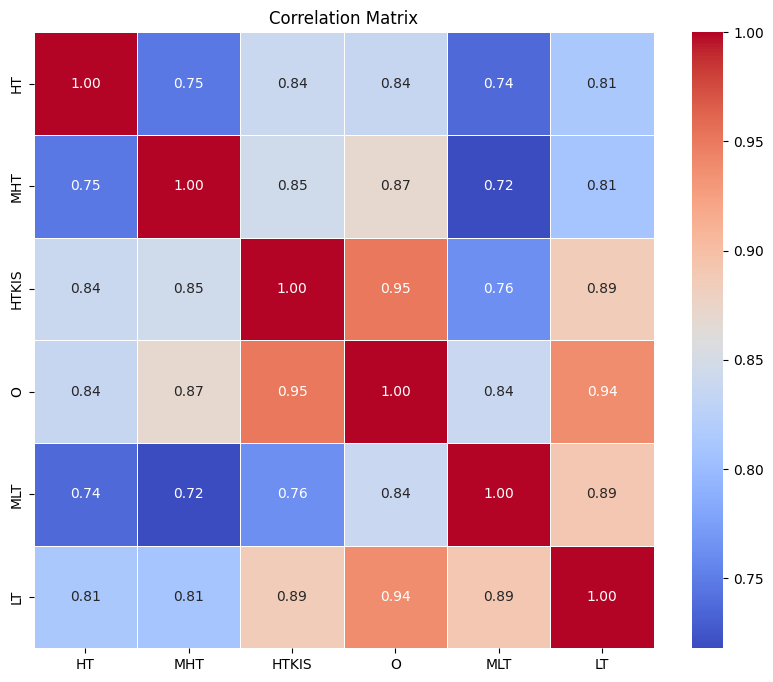

In [33]:
import seaborn as sns

corr_matrix = grid_counts_powiaty.iloc[:, 2:8].corr()



plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5 )
plt.title('Correlation Matrix')
plt.show()

## Location Quotient

In [230]:
import pandas as pd

bins = [0, 1, float('inf')]
labels = ['Low_LQ', 'High_LQ']

sector_counts = pd.DataFrame()
grid_occurences = pd.DataFrame()


for column in ['LQ_O', 'LQ_HTKIS', 'LQ_MLT', 'LQ_LT', 'LQ_MHT', 'LQ_HT']:
    grid_occurences[f'{column}_Firm_Count_Category'] = pd.cut(grid_counts_powiaty[column], bins=bins, labels=labels, right=False)
    sector_count = grid_occurences.groupby(f'{column}_Firm_Count_Category').size().reset_index(name=column)
    sector_count = sector_count.set_index(f'{column}_Firm_Count_Category').T
    sector_counts = pd.concat([sector_counts, sector_count])


sector_counts = sector_counts.fillna(0).astype(int)


sector_counts_sorted = sector_counts.sort_values(by = 'High_LQ', ascending= False)
sector_counts_sorted

,Low_LQ,High_LQ
LQ_O,4256,28966
LQ_MLT,26692,6530
LQ_LT,28131,5091
LQ_HTKIS,30622,2600
LQ_MHT,31515,1707
LQ_HT,32504,718


<Figure size 600x800 with 0 Axes>

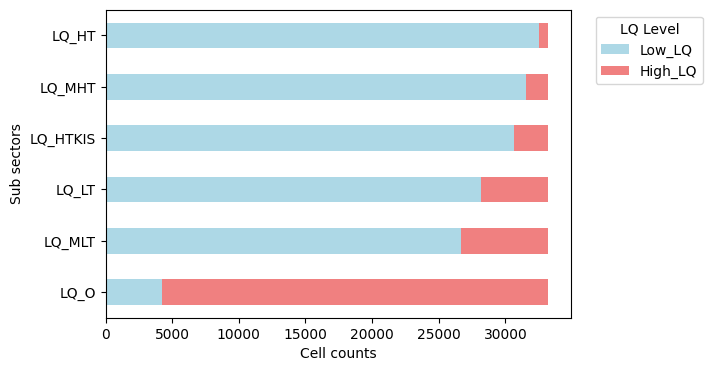

In [362]:
import matplotlib.pyplot as plt

# Define colors
colors = ['lightblue', 'lightcoral']

# Plot
plt.figure(figsize=(6, 8))
sector_counts_sorted.plot(kind='barh', stacked=True, color=colors, figsize=(6, 4))
plt.xlabel('Cell counts')
plt.ylabel('Sub sectors')
plt.legend(title='LQ Level', labels=['Low_LQ', 'High_LQ'], loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()


## Spatial distribution plots

In [ ]:
def generate_heatmap_for_group(group_df, group_name):
    
    grid_gdf_counted = count_firms_on_grid(group_df, group_name, grid_gdf)

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 30, 150, 3000]
    elif group_name in ['O']:
        bounds = [0, 1, 50, 150, 500, 10000]
    else:
        bounds = [0, 1, 5, 10, 20, 50]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    grid_gdf_counted.plot(column='firm_count', cmap=cmap, norm=norm, linewidth=0, ax=ax, edgecolor='grey', legend=True)
    
    # Plot Mazovian boundaries
    powiaty_maz.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.6)
    # Plot cities
    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']
    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()

# Assuming group_names is defined elsewhere in your code
for group_name in group_names:
    group_df = gdf[gdf['Group'] == group_name]
    generate_heatmap_for_group(group_df, group_name)

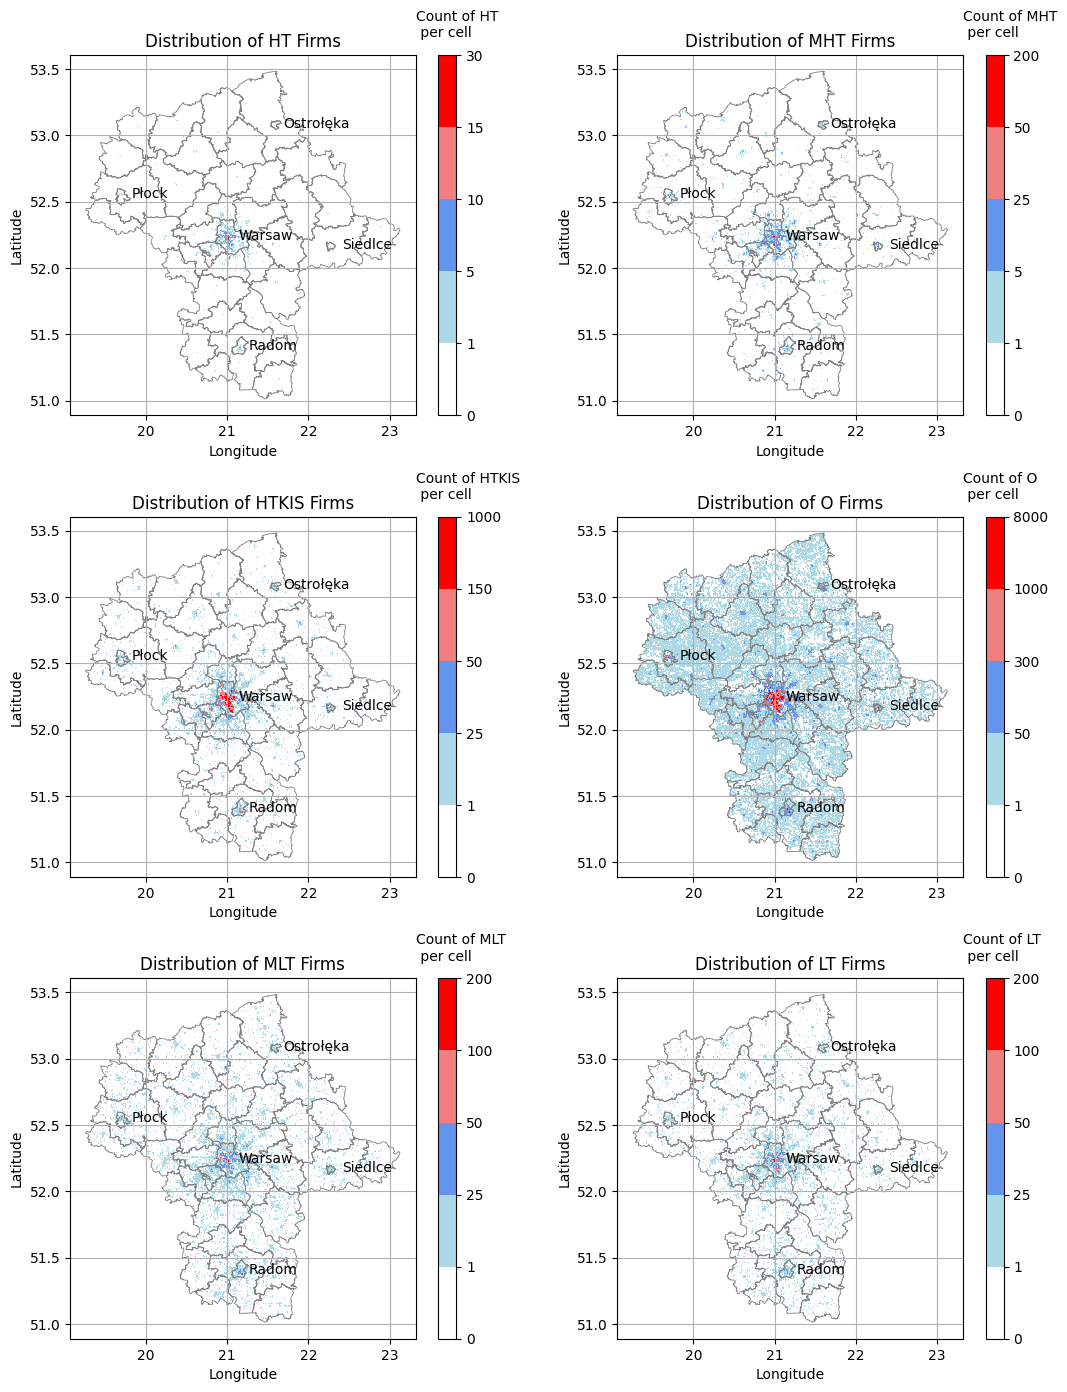

In [312]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def generate_heatmap_for_group(group_df, group_name, ax):
    
    grid_gdf_counted = count_firms_on_grid(group_df, group_name, grid_gdf)

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['MHT']:
        bounds = [0, 1, 5, 25, 50, 200]
    elif group_name in ['HT']:
        bounds = [0, 1, 5, 10, 15, 30]
    elif group_name in ['HTKIS']:
        bounds = [0, 1, 25, 50, 150, 1000]
    elif group_name in ['O']:
        bounds = [0, 1, 50, 300, 1000, 8000]
    elif group_name in ['MLT']:
        bounds = [0, 1, 25, 50, 100, 200]
    elif group_name in ['LT']:
        bounds = [0, 1, 25, 50, 100, 200]


    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors), clip=True)

    # Plot heatmap
    im = grid_gdf_counted.plot(column='firm_count', cmap=cmap, norm=norm, linewidth=0, ax=ax, edgecolor='grey', legend=True)
    # Plot Mazovian boundaries
    powiaty_maz.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.6)
    # Plot cities
    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']
    for city, lon, lat in zip(city_names, city_lon, city_lat):
        ax.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Distribution of {group_name} Firms')
    
    # Add custom legend
    ax.annotate(f'Count of {group_name}\n per cell' , xy=(1, 1.05), xycoords='axes fraction', fontsize=10, ha='left')

    ax.grid(True)

group_names = ['HT', 'MHT', 'HTKIS', 'O', 'MLT', 'LT']

# Assuming group_names is defined elsewhere in your code
fig, axes = plt.subplots(3, 2, figsize=(11, 14))

for i, group_name in enumerate(group_names):
    group_df = gdf[gdf['Group'] == group_name]
    row = i // 2
    col = i % 2
    generate_heatmap_for_group(group_df, group_name, axes[row, col])

plt.tight_layout()
plt.show()


## DBSCAN clustering

In [ ]:
# import numpy as np
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score

# X = gdf_ht[['lon', 'lat']].values

# # Define range of parameters to search
# eps_values = np.arange(0.01, 0.16, 0.01) # Adjust according to your data
# min_samples_values = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust according to your data

# # Initialize variables to store silhouette scores
# silhouette_scores = []

# # Loop through all combinations of eps and min_samples
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Initialize DBSCAN with current parameters
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X)
        
#         # Compute silhouette score
#         silhouette = silhouette_score(X, labels)
#         silhouette_scores.append(silhouette)

# # Reshape silhouette scores for plotting
# silhouette_scores = np.array(silhouette_scores).reshape(len(eps_values), len(min_samples_values))

# # Plotting
# plt.figure(figsize=(10, 6))
# for i, eps in enumerate(eps_values):
#     plt.plot(min_samples_values, silhouette_scores[i], marker='o', label=f'eps = {eps}')

# plt.title('Elbow Plot for Silhouette Score')
# plt.xlabel('min_samples')
# plt.ylabel('Silhouette Score')
# plt.legend(title='eps')
# plt.grid(True)
# plt.xticks(min_samples_values)
# plt.show()



# DBSCAN grid search HT


In [ ]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score

# best_eps = None
# best_min_samples = None
# best_silhouette_score = -1  # Initialize with a value lower than the possible silhouette score range

# gdf_HT7 = gdf[gdf['Group'] == 'HT']

# X = gdf_HT7[['lon', 'lat']].values


# eps_values = np.arange(0.01, 0.11, 0.005) # Adjust according to your data
# min_samples_values = [5, 6, 7, 8, 9, 10]  # Adjust according to your data

# # Loop through all combinations of eps and min_samples
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Initialize DBSCAN with current parameters
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X)
        
#         # Check if only one cluster is found
#         if len(np.unique(labels)) <= 1:
#             continue
        
#         # Compute silhouette score
#         silhouette = silhouette_score(X, labels)
        
#         # Update best parameters and silhouette score if current silhouette score is higher
#         if silhouette > best_silhouette_score:
#             best_eps = eps
#             best_min_samples = min_samples
#             best_silhouette_score = silhouette

# # Print the best parameters and silhouette score
# print(f"Best eps: {best_eps}")
# print(f"Best min_samples: {best_min_samples}")
# print(f"Best silhouette score: {best_silhouette_score}")

In [ ]:
# Best eps: 0.10499999999999998
# Best min_samples: 5
# Best silhouette score: 0.6164373963652019

Labels: [0 1 0 ... 0 0 0]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12]


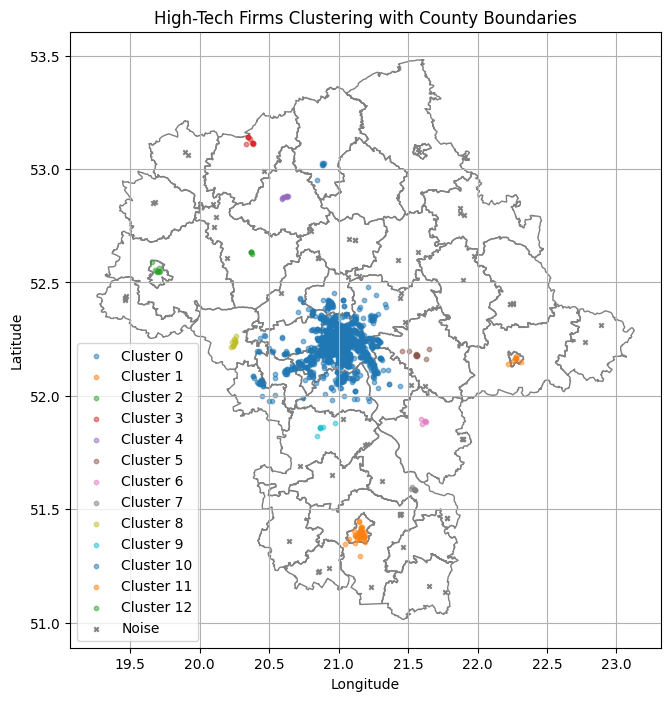

Silhouette Score: 0.5147390204300047


In [364]:
from sklearn.cluster import DBSCAN

gdf_HT= gdf[gdf['Group'] == 'HT']

X = gdf_HT[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.10 # Adjust according to your data
min_samples = 5  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

silhouette = silhouette_score(X, labels)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

print(f"Silhouette Score: {silhouette}")

gdf_HT['clusters'] = labels

# DBSCAN grid search MHT

In [58]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics.pairwise import euclidean_distances

# best_eps = None
# best_min_samples = None
# best_avg_intra_cluster_distance = float('inf')  # Initialize with a value lower than the possible silhouette score range

# gdf_MHT7 = gdf[gdf['Group'] == 'MHT']

# X = gdf_MHT7[['lon', 'lat']].values


# eps_values = np.arange(0.01, 0.11, 0.01) # Adjust according to your data
# min_samples_values = [10,20,30,35,40,45,50,55,60,65,70]  # Adjust according to your data

# # Loop through all combinations of eps and min_samples
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Initialize DBSCAN with current parameters
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X)
        
#         # Check if only noise points are detected
#         if len(np.unique(labels)) == 1 and -1 in labels:
#             continue
        
#         # Compute representative points for each cluster
#         cluster_centers = []
#         for label in np.unique(labels):
#             if label == -1:  # Ignore noise points
#                 continue
#             cluster_points = X[labels == label]
#             cluster_center = cluster_points.mean(axis=0)
#             cluster_centers.append(cluster_center)
        
#         # Compute intra-cluster distances
#         intra_cluster_distances = []
#         for label, cluster_center in zip(np.unique(labels), cluster_centers):
#             if label == -1:  # Ignore noise points
#                 continue
#             cluster_points = X[labels == label]
#             distances = euclidean_distances(cluster_points, [cluster_center])
#             intra_cluster_distances.extend(distances)
        
#         # Compute average intra-cluster distance
#         avg_intra_cluster_distance = np.mean(intra_cluster_distances)
        
#         # Update best parameters and average intra-cluster distance if current value is lower
#         if avg_intra_cluster_distance < best_avg_intra_cluster_distance:
#             best_eps = eps
#             best_min_samples = min_samples
#             best_avg_intra_cluster_distance = avg_intra_cluster_distance

# # Print the best parameters and average intra-cluster distance
# print(f"Best eps: {best_eps}")
# print(f"Best min_samples: {best_min_samples}")
# print(f"Best average intra-cluster distance: {best_avg_intra_cluster_distance}")

In [59]:
# Best eps: 0.14
# Best min_samples: 60
# Best silhouette score: 0.5903037061048774

Labels: [ 0  1  1 ...  1 -1 -1]
Unique Labels: [-1  0  1  2  3  4]


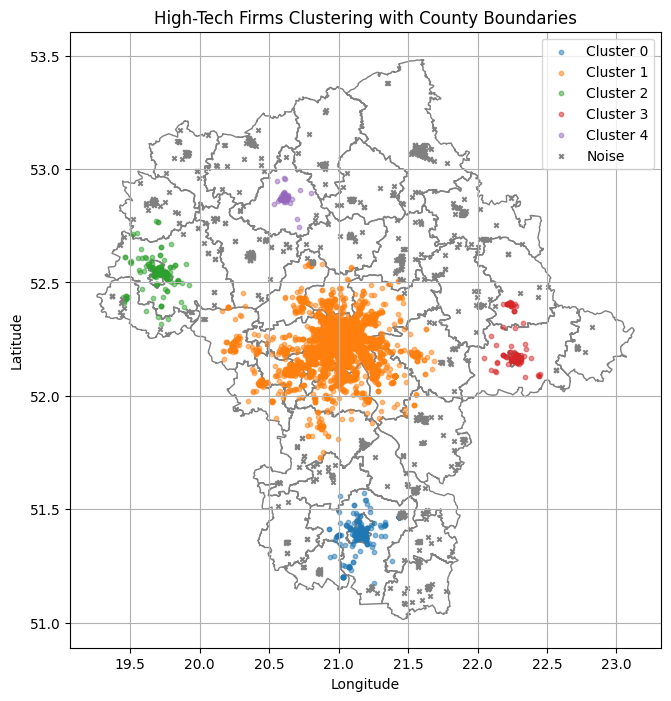

In [365]:
from sklearn.cluster import DBSCAN

gdf_MHT= gdf[gdf['Group'] == 'MHT']

X = gdf_MHT[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.14  # Adjust according to your data
min_samples = 60  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

gdf_MHT['clusters'] = labels

# DBSCAN grid search HTKIS

In [61]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score

# best_eps = None
# best_min_samples = None
# best_silhouette_score = -1  # Initialize with a value lower than the possible silhouette score range

# gdf_HTKIS= gdf[gdf['Group'] == 'HTKIS']

# X = gdf_HTKIS[['lon', 'lat']].values


# eps_values = np.arange(0.01, 0.11, 0.01) # Adjust according to your data
# min_samples_values = [40,50,55,60,65,70,]  # Adjust according to your data

# # Loop through all combinations of eps and min_samples
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Initialize DBSCAN with current parameters
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X)
        
#         # Check if only one cluster is found
#         if len(np.unique(labels)) <= 1:
#             continue
        
#         # Compute silhouette score
#         silhouette = silhouette_score(X, labels)
        
#         # Update best parameters and silhouette score if current silhouette score is higher
#         if silhouette > best_silhouette_score:
#             best_eps = eps
#             best_min_samples = min_samples
#             best_silhouette_score = silhouette

# # Print the best parameters and silhouette score
# print(f"Best eps: {best_eps}")
# print(f"Best min_samples: {best_min_samples}")
# print(f"Best silhouette score: {best_silhouette_score}")

In [62]:
# Best eps: 0.09999999999999999
# Best min_samples: 55
# Best silhouette score: 0.685568621690414

Labels: [0 1 1 ... 1 1 1]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]


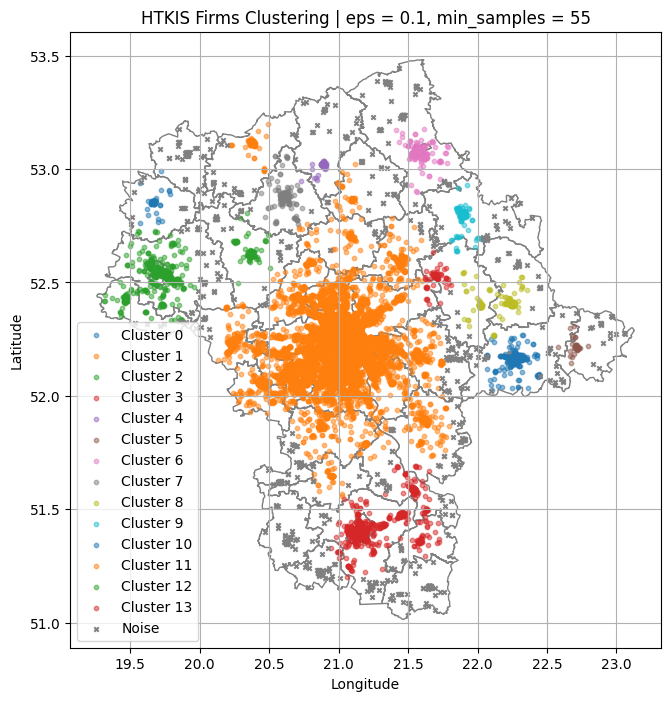

Silhouette Score: 0.685568621690414


In [367]:
from sklearn.cluster import DBSCAN

gdf_HTKIS= gdf[gdf['Group'] == 'HTKIS']

X = gdf_HTKIS[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.1  # Adjust according to your data
min_samples = 55  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

silhouette = silhouette_score(X, labels)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('HTKIS Firms Clustering | eps = 0.1, min_samples = 55')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

print(f"Silhouette Score: {silhouette}")

gdf_HTKIS['clusters'] = labels

# DBSCAN grid search PMHT

In [64]:
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import silhouette_score

# best_eps = None
# best_min_samples = None
# best_silhouette_score = -1  # Initialize with a value lower than the possible silhouette score range

# gdf_PMHT= gdf[gdf['Group'] == 'PMHT']

# X = gdf_PMHT[['lon', 'lat']].values


# eps_values = np.arange(0.01, 0.15, 0.01) # Adjust according to your data
# min_samples_values = [10, 15, 20, 25, 30 , 35, 40]  # Adjust according to your data

# # Loop through all combinations of eps and min_samples
# for eps in eps_values:
#     for min_samples in min_samples_values:
#         # Initialize DBSCAN with current parameters
#         dbscan = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = dbscan.fit_predict(X)
        
#         # Check if only one cluster is found
#         if len(np.unique(labels)) <= 1:
#             continue
        
#         # Compute silhouette score
#         silhouette = silhouette_score(X, labels)
        
#         # Update best parameters and silhouette score if current silhouette score is higher
#         if silhouette > best_silhouette_score:
#             best_eps = eps
#             best_min_samples = min_samples
#             best_silhouette_score = silhouette

# # Print the best parameters and silhouette score
# print(f"Best eps: {best_eps}")
# print(f"Best min_samples: {best_min_samples}")
# print(f"Best silhouette score: {best_silhouette_score}")

In [65]:
# Best eps: 0.14
# Best min_samples: 15
# Best silhouette score: 0.7197084593810997

# DBSCAN MLT

Labels: [0 5 0 ... 0 0 6]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11]


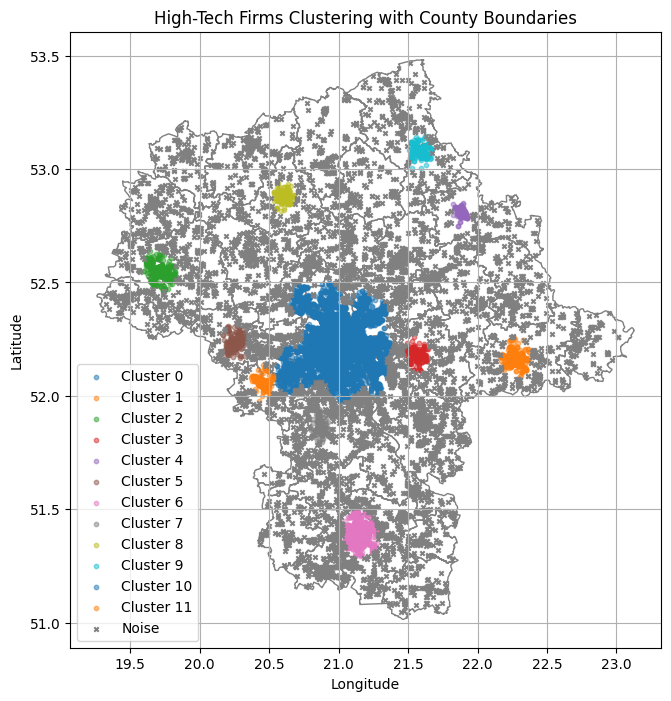

Silhouette Score: 0.1320336609364


In [369]:
from sklearn.cluster import DBSCAN

gdf_MLT= gdf[gdf['Group'] == 'MLT']

X = gdf_MLT[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.05  # Adjust according to your data
min_samples = 200  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

silhouette = silhouette_score(X, labels)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

print(f"Silhouette Score: {silhouette}")

gdf_MLT['clusters'] = labels

# DBSCAN O

In [68]:
from sklearn.cluster import DBSCAN

gdf_O= gdf[gdf['Group'] == 'O']

X = gdf_O[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.02  # Adjust according to your data
min_samples = 1000  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# # Plotting
# ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# # Plot clusters of high-tech firms
# for label in unique_labels:
#     if label == -1:
#         continue
#     cluster_points = X[labels == label]
#     plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)


# silhouette = silhouette_score(X, labels)

# # Plot noise points separately
# noise_points = X[labels == -1]
# plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.title('High-Tech Firms Clustering with County Boundaries')
# plt.grid(True)

# # Add legend for points only
# plt.legend()

# plt.show()

# print(f"Silhouette Score: {silhouette}")

gdf_O['clusters'] = labels

Labels: [ 0 -1  0 ...  0  0  0]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36]


# DBSCAN LT

Labels: [0 0 0 ... 0 0 0]
Unique Labels: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


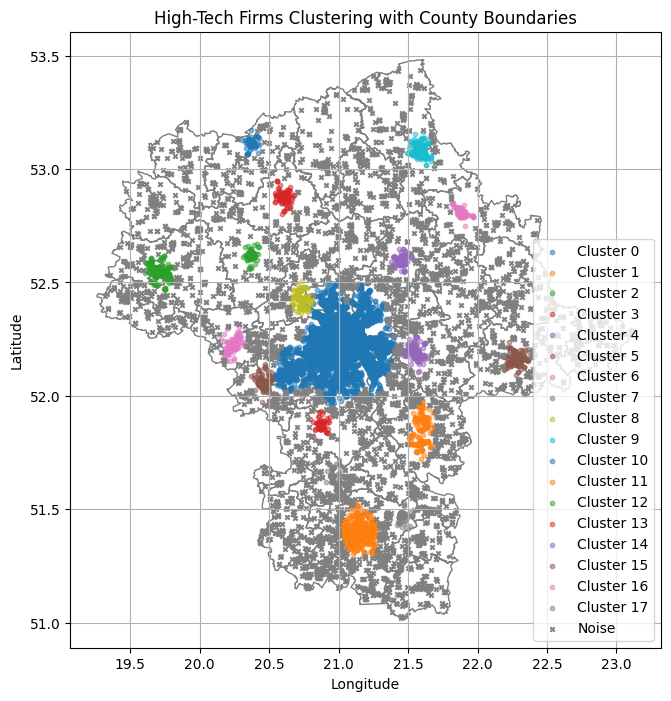

In [69]:
from sklearn.cluster import DBSCAN

gdf_LT= gdf[gdf['Group'] == 'LT']

X = gdf_LT[['lon', 'lat']].values

# DBSCAN parameters
eps = 0.05  # Adjust according to your data
min_samples = 100  # Adjust according to your data

# DBSCAN clustering
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X)
labels = dbscan.labels_
unique_labels = np.unique(labels)

print("Labels:", labels)
print("Unique Labels:", unique_labels)

# Plotting
ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

# Plot clusters of high-tech firms
for label in unique_labels:
    if label == -1:
        continue
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {label}', s=10, alpha=0.5)

# Plot noise points separately
noise_points = X[labels == -1]
plt.scatter(noise_points[:, 0], noise_points[:, 1], label='Noise', color='gray', marker='x', s=10)


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Clustering with County Boundaries')
plt.grid(True)

# Add legend for points only
plt.legend()

plt.show()

gdf_LT['clusters'] = labels

In [98]:
gdf_clusters = pd.concat([gdf_HT, gdf_MHT, gdf_HTKIS, gdf_MLT, gdf_O, gdf_LT])

In [99]:
gdf_clusters['clusters'] = gdf_clusters['clusters'].replace(-1, "noise")

In [100]:
gdf_clusters.loc[gdf_clusters['clusters'] != 'noise', 'clusters'] = 'cluster'


In [101]:
gdf_clusters['clusters'].value_counts()

clusters
cluster    656802
noise      326913
Name: count, dtype: int64

In [102]:
gdf_clusters.groupby('Group')['clusters'].value_counts()

Group  clusters
HT     cluster       2026
       noise          147
HTKIS  cluster      54688
       noise         2086
LT     cluster      24165
       noise         6027
MHT    cluster       6740
       noise         1066
MLT    cluster      27442
       noise         9581
O      cluster     541741
       noise       308006
Name: count, dtype: int64

In [103]:
import pandas as pd

# Group the DataFrame by 'Group' and 'clusters' columns and count the occurrences
group_clusters_counts = gdf_clusters.groupby('Group')['clusters'].value_counts()
group_clusters_counts_df = group_clusters_counts.unstack().fillna(0)

# Calculate the total count for each group
group_total_counts = group_clusters_counts_df.sum(axis=1)

# Calculate the percentage ratios
percentage_ratios = group_clusters_counts_df.div(group_total_counts, axis=0) * 100

# Merge the percentage ratios with the original counts DataFrame
group_clusters_counts_with_ratios = pd.concat([group_clusters_counts_df, percentage_ratios], axis=1, keys=['Count', 'Percentage'])

# Print or use the resulting DataFrame
group_clusters_counts_with_ratios.sort_values(by=('Percentage', 'noise'), ascending=False)


Count         Percentage           
clusters cluster   noise    cluster      noise
Group                                         
O         541741  308006  63.753211  36.246789
MLT        27442    9581  74.121492  25.878508
LT         24165    6027  80.037758  19.962242
MHT         6740    1066  86.343838  13.656162
HT          2026     147  93.235159   6.764841
HTKIS      54688    2086  96.325783   3.674217

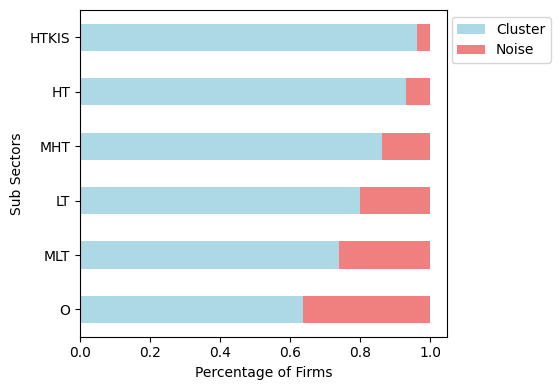

In [363]:
import matplotlib.pyplot as plt

group_clusters_counts = gdf_clusters.groupby('Group')['clusters'].value_counts(normalize=True)
group_clusters_counts_df = group_clusters_counts.unstack().fillna(0).sort_values(by='cluster', ascending=True)

colors = ['lightblue', 'lightcoral']
# Plotting
group_clusters_counts_df.plot(kind='barh', stacked=True, figsize=(6, 4), color  = colors)
plt.xlabel('Percentage of Firms')
plt.ylabel('Sub Sectors')
plt.legend( labels=['Cluster', 'Noise'], loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()


Final DBSCAN 

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

gdf_non_ht = gdf[gdf['if_hightech'] == 0]

min_lon, max_lon = gdf['lon'].min(), gdf['lon'].max()
min_lat, max_lat = gdf['lat'].min(), gdf['lat'].max()
grid_size = 0.01182 

lons = np.arange(min_lon, max_lon, grid_size)
lats = np.arange(min_lat, max_lat, grid_size)

gdf_non_ht['grid_x'] = np.digitize(gdf_non_ht['lon'], lons)
gdf_non_ht['grid_y'] = np.digitize(gdf_non_ht['lat'], lats)

grid_counts_non_ht = gdf_non_ht.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')

heatmap_non_ht= np.zeros((len(lats), len(lons)))

for idx, row in grid_counts_non_ht.iterrows():
    grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
    count = row['firm_count']
    heatmap_non_ht[grid_y, grid_x] = count

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_non_ht, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of non High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()


## Previous approaches (other, not-used stuff)

In [ ]:

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

min_lon_all, max_lon_all = gdf['lon'].min(), gdf['lon'].max()
min_lat_all, max_lat_all = gdf['lat'].min(), gdf['lat'].max()

def generate_heatmap_for_group(group_name):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()

    # Define grid size (adjust according to your needs)
    grid_size = 0.0093

    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon_all, max_lon_all, grid_size)
    lats = np.arange(min_lat_all, max_lat_all, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])


    # Create a copy of the merged DataFrame with a name like gdf_groupname
    globals()[f"gdf_{group_name}"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
    city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
    city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_all, max_lon_all, min_lat_all, max_lat_all], alpha=0.7)

    for city, lon, lat in zip(city_names, city_lon, city_lat):
        plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

    plt.colorbar(img, label='Count of Firms')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Heatmap of {group_name} Firms')
    plt.grid(True)
    plt.show()


group_names = ['O', 'KIS', 'HTKIS', 'MLT', 'LT', 'MHT', 'HT', 'PMHT']

dfs = []

for group_name in group_names:
    generate_heatmap_for_group(group_name)
    dfs.append(globals()[f"gdf_{group_name}"])

gdf_counts= pd.concat(dfs, ignore_index=True)

In [ ]:
# Aggregate firm counts for each group within each cell
grid_data_aggregated = gdf_counts.groupby(['grid_x', 'grid_y', 'Group'])['firm_count'].first().reset_index()

# Pivot the aggregated DataFrame to create separate columns for firm counts for each group in each cell
grid_data_pivoted = grid_data_aggregated.pivot_table(index=['grid_x', 'grid_y'], columns='Group', values='firm_count').reset_index()

# Fill NA with 0
grid_data_pivoted = grid_data_pivoted.fillna(0)

# Merge grid_data_pivoted with gdf_coutns
grid_data = gdf_counts.merge(grid_data_pivoted, on=['grid_x', 'grid_y'], how='left')

# Drop duplicated grid cells
grid_data = grid_data.drop_duplicates(subset=['grid_x', 'grid_y'])

# Sort the DataFrame by 'grid_x' and 'grid_y'
grid_data = grid_data.sort_values(['grid_x', 'grid_y'])

# Add a new column 'grid_xy' with the numbering of grid cells
grid_data['grid_xy'] = np.arange(1, grid_data.shape[0] + 1)

In [ ]:
grid_counts = grid_data.iloc[:, 64:].reset_index()
grid_counts

In [ ]:
groups = ['HTKIS', 'MLT', 'LT', 'MHT', 'O', 'KIS', 'HT']

In [ ]:
for group in groups:
    group_count = grid_counts[group].sum()
    grid_counts[f'cell_{group}_to_{group}_total'] = grid_counts[group] / group_count 

In [ ]:
for group in groups:
    grid_counts[f'cell_{group}_to_cell_total'] = grid_counts[group] / grid_counts['firm_count']

In [ ]:
import matplotlib.pyplot as plt

# Calculate the maximum values for each column
max_values = grid_counts.iloc[:, 11:].max().sort_values(ascending=False)

# Plot the maximum values
plt.figure(figsize=(10, 6))
max_values.plot(kind='bar', color='skyblue')
plt.xlabel('Group')
plt.ylabel('Max Firm Count')
plt.title('Maximum Firm Count for Each Group')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

predictors = ['locHH', 'lon', 'lat', 'empl', 'sharesEMPL2', 'locPdens', 'locBIG', 'locAggTOTAL', 'locHightech', 'locLQ', 'dist_core_10', 
              'dist_core_25', 'dist_core_50', 'dist_midsize_10', 'dist_midsize_25', 'dist_midsize_50', 'dist_regional_10', 'dist_regional_25', 
              'dist_regional_50', 'dist_localbig_10', 'dist_localbig_25', 'dist_localbig_50', 'dist_localsmall_10', 'dist_localsmall_25', 'dist_localsmall_50']

y = gdf['if_hightech']
X = gdf[predictors]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Random Forest Classifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))


In [ ]:
# Get feature importances from the trained model
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to store feature names and their importances
feature_importance_df = pd.DataFrame({'Feature': predictors, 'Importance': feature_importances})

# Sort the DataFrame by importance values in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the top N most important features
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Invert y-axis to display the most important features at the top
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = rf_classifier.predict(X_test)
confusion_matrix(y_test, y_pred)

In [ ]:
import scikit-plot as skplt


skplt.metrics.plot_confusion_matrix(y_train, y_pred)


In [ ]:
import geopandas as gpd
from pysal.lib import weights
from pysal.explore import esda
import matplotlib.pyplot as plt
from splot.esda import plot_moran


group_names = gdf_counts['Group'].unique()

for group_name in group_names:

    group_df = gdf_counts[gdf_counts['Group'] == group_name]
    w = weights.Queen.from_dataframe(group_df)
    moran = esda.Moran(group_df['firm_count'], w)
    
    print(f"\nMoran's I for {group_name}:")
    print("Moran's I:", moran.I)
    print("Moran's I p-value:", moran.p_sim)

Heatmaps of all the groups for grid 1, 2, 5km

In [ ]:
def generate_heatmap_for_group(group_name, grid_size, ax):
    # Filter DataFrame for the specified group
    group_df = gdf[gdf['Group'] == group_name]
    
    # Calculate min and max values for lon and lat for the filtered DataFrame
    min_lon, max_lon = group_df['lon'].min(), group_df['lon'].max()
    min_lat, max_lat = group_df['lat'].min(), group_df['lat'].max()
    
    
    # Generate grid of lon and lat values
    lons = np.arange(min_lon, max_lon, grid_size)
    lats = np.arange(min_lat, max_lat, grid_size)
    
    # Digitize lon and lat values
    group_df['grid_x'] = np.digitize(group_df['lon'], lons)
    group_df['grid_y'] = np.digitize(group_df['lat'], lats)
    
    # Group by grid coordinates and count firms
    grid_counts = group_df.groupby(['grid_x', 'grid_y']).size().reset_index(name='firm_count')
    group_df = group_df.merge(grid_counts, how='left', on=['grid_x', 'grid_y'])

    # Create a copy of the merged DataFrame with a name like gdf_groupname_gridsize
    globals()[f"gdf_{group_name}_{int(grid_size*1000)}m"] = group_df.copy()

    # Create heatmap matrix
    heatmap = np.zeros((len(lats), len(lons)))
    
    # Populate heatmap matrix with counts
    for idx, row in grid_counts.iterrows():
        grid_x, grid_y = row['grid_x'] - 1, row['grid_y'] - 1  
        count = row['firm_count']
        heatmap[grid_y, grid_x] = count

    # Define colors and bounds based on group_name
    colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
    if group_name in ['HTKIS', 'MLT', 'LT', 'MHT', 'PMHT']:
        bounds = [0, 1, 5, 50, 150, 3000]
    elif group_name in ['O', 'KIS']:
        bounds = [0, 1, 30, 100, 400, 3000]
    else:
        bounds = [0, 1, 5, 15, 50, 300]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, len(colors))    
    
    # Plot heatmap
    img = ax.imshow(heatmap, cmap=cmap, norm=norm, origin='lower', extent=[min_lon, max_lon, min_lat, max_lat], alpha=0.7)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Firm Count Heatmap of {group_name} (Grid Size: {int(grid_size*1000)}m)')
    ax.grid(True)
    plt.colorbar(img, ax=ax, label='Firm Count')


# Define grid configurations
grid_sizes = [0.01182, 0.02365, 0.05912]  # Grid sizes in degrees (1km, 2km, and 5km)

# Create subplots for each group with different grid configurations
fig, axes = plt.subplots(len(group_names), len(grid_sizes), figsize=(40,40))

# Generate heatmap for each group with different grid configurations
for i, group_name in enumerate(group_names):
    for j, grid_size in enumerate(grid_sizes):
        ax = axes[i, j]
        generate_heatmap_for_group(group_name, grid_size, ax)

plt.tight_layout()
plt.show()


Previous approach Grid high-tech Warsaw

In [ ]:
warsaw_ht = warsaw[warsaw['if_hightech'] == 1]

In [ ]:
min_lon_waw, max_lon_waw = warsaw['lon'].min(), warsaw['lon'].max()
min_lat_waw, max_lat_waw = warsaw['lat'].min(), warsaw['lat'].max()
grid_size = 0.01182  # Adjust as needed

lons_waw = np.arange(min_lon_waw, max_lon_waw, grid_size)
lats_waw = np.arange(min_lat_waw, max_lat_waw, grid_size)

warsaw_ht['grid_x_waw_ht'] = np.digitize(warsaw_ht['lon'], lons_waw)
warsaw_ht['grid_y_waw_ht'] = np.digitize(warsaw_ht['lat'], lats_waw)

grid_counts_waw = warsaw_ht.groupby(['grid_x_waw_ht', 'grid_y_waw_ht']).size().reset_index(name='firm_count_waw_ht')
warsaw_ht = warsaw_ht.merge(grid_counts_waw, how='left', on=['grid_x_waw_ht', 'grid_y_waw_ht'])

In [ ]:
heatmap_waw = np.zeros((len(lats_waw), len(lons_waw)))

for idx, row in grid_counts_waw.iterrows():
    grid_x, grid_y = row['grid_x_waw_ht'] - 1, row['grid_y_waw_ht'] - 1  
    count = row['firm_count_waw_ht']
    heatmap_waw[grid_y, grid_x] = count

In [ ]:
colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 50, 150, 1000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = dzielnice.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_waw, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_waw, max_lon_waw, min_lat_waw, max_lat_waw], alpha=0.7)

# plt.scatter(warsaw_ht['lon'], warsaw_ht['lat'], color='black', marker='o', s = 0.01)
plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gdf_ht = gdf[gdf['if_hightech'] == 1]

In [ ]:
min_lon_maz, max_lon_maz = gdf_ht['lon'].min(), gdf_ht['lon'].max()
min_lat_maz, max_lat_maz = gdf_ht['lat'].min(), gdf_ht['lat'].max()
grid_size = 0.02912

lons_maz = np.arange(min_lon_maz, max_lon_maz, grid_size)
lats_maz = np.arange(min_lat_maz, max_lat_maz, grid_size)

gdf_ht['grid_x_maz_ht'] = np.digitize(gdf_ht['lon'], lons_maz)
gdf_ht['grid_y_maz_ht'] = np.digitize(gdf_ht['lat'], lats_maz)

grid_counts_maz = gdf_ht.groupby(['grid_x_maz_ht', 'grid_y_maz_ht']).size().reset_index(name='firm_count_maz_ht')
gdf_ht = gdf_ht.merge(grid_counts_maz, how='left', on=['grid_x_maz_ht', 'grid_y_maz_ht'])

heatmap_maz = np.zeros((len(lats_maz), len(lons_maz)))

for idx, row in grid_counts_maz.iterrows():
    grid_x, grid_y = row['grid_x_maz_ht'] - 1, row['grid_y_maz_ht'] - 1  
    count = row['firm_count_maz_ht']
    heatmap_maz[grid_y, grid_x] = count


city_lon = [21.017532, 21.14714, 19.70638, 22.29006, 21.5714]
city_lat = [52.237049, 51.40253, 52.54682, 52.16772, 53.0813]
city_names = ['Warsaw', 'Radom', 'Płock', 'Siedlce', 'Ostrołęka']

colors = ['white', 'lightblue', 'cornflowerblue', 'lightcoral', 'red']
bounds = [0, 1, 5, 30, 100, 2000]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, len(colors))

ax = powiaty_maz.plot(figsize=(12, 8), color='none', edgecolor='grey')

plt.imshow(heatmap_maz, cmap=cmap, norm=norm, origin='lower', extent=[min_lon_maz, max_lon_maz, min_lat_maz, max_lat_maz], alpha=0.7)

for city, lon, lat in zip(city_names, city_lon, city_lat):
    plt.annotate(city, xy=(lon, lat), xytext=(7, -2), textcoords='offset points', color='black', fontsize=10)

plt.colorbar(label='Count of High-Tech Firms')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('High-Tech Firms Heatmap')

plt.grid(True)
plt.show()


Buffer initial

In [ ]:
import geopandas as gpd
from shapely.geometry import Point

radius =  0.00734 
gdf_ht['buffer'] = gdf_ht.geometry.buffer(radius)

target_variable = []

for index, location in gdf_ht.iterrows():
    high_tech_firms_within_radius = gdf_ht[gdf_ht.geometry.within(location['buffer'])]
    num_high_tech_firms = len(high_tech_firms_within_radius)
    target_variable.append(num_high_tech_firms)

gdf_ht['high_tech_firm_clustering'] = target_variable
